# Machine Learning – Unidad 2  

## Introducción

En la **Unidad 1** se construyó un pipeline reproducible de análisis de datos usando el dataset **House Prices**, abordando exploración, limpieza, imputación de datos faltantes y separación en muestras de entrenamiento, validación y test.

Para esta **Unidad 2**, el mismo problema se reformula como una **clasificación binaria**. En lugar de predecir `SalePrice` como valor continuo, se construye una variable objetivo binaria denominada `HighPrice`, donde:

- `HighPrice = 1` si el precio de la vivienda está sobre la mediana de `SalePrice`.
- `HighPrice = 0` si el precio está en o bajo la mediana.

Esta reformulación permite cumplir con la pauta de la actividad, que solicita entrenar y comparar distintos **modelos supervisados de clasificación binaria**, evaluar su desempeño con métricas apropiadas, optimizar hiperparámetros y seleccionar un modelo final.

---

## Objetivos del trabajo

1. Entrenar distintos modelos supervisados:
   - Regresión logística penalizada (L1, L2 y ElasticNet)
   - Random Forest
   - XGBoost
   - Red neuronal simple

2. Calcular métricas de desempeño en entrenamiento y validación:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - AUC
   - KS

3. Proponer y aplicar un método de optimización de hiperparámetros.

4. Interpretar resultados y justificar la selección del modelo final.

5. Dejar el desarrollo listo para ser subido a GitHub.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, Input
    from tensorflow.keras.optimizers import Adam
    TF_OK = True
except Exception:
    TF_OK = False

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("XGBoost disponible:", XGB_OK)
print("TensorFlow disponible:", TF_OK)

Pandas: 2.2.2
NumPy: 2.0.2
XGBoost disponible: True
TensorFlow disponible: True


## Punto 1. Preparación de datos y reformulación del problema

Para ajustar el trabajo a la exigencia de **clasificación binaria**, se construye la variable `HighPrice` a partir de la mediana de `SalePrice`.  
Luego, se reutiliza la lógica de preprocesamiento desarrollada en la Unidad 1:

- imputación de variables numéricas con mediana,
- imputación de variables categóricas con moda,
- estandarización de variables numéricas,
- codificación One-Hot de variables categóricas.

Se realiza una división en tres muestras:

- **Entrenamiento:** 70%
- **Validación:** 15%
- **Test:** 15%

La estratificación se aplica sobre `HighPrice` para conservar la proporción de clases.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [ ]:
print("Dimensiones originales:", df.shape)
df.head()

Dimensiones originales: (1460, 82)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HighPrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,1
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,1
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,1
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,1


In [ ]:
# 3. Crear objetivo binario
threshold = df["SalePrice"].median()
df["HighPrice"] = (df["SalePrice"] > threshold).astype(int)

print("Mediana de SalePrice:", threshold)
print("\nDistribución de clases (proporción):")
print(df["HighPrice"].value_counts(normalize=True).rename("proportion"))

# Variables predictoras y target
X = df.drop(columns=["SalePrice", "HighPrice"])
y = df["HighPrice"]

Mediana de SalePrice: 163000.0

Distribución de clases (proporción):
HighPrice
0    0.50137
1    0.49863
Name: proportion, dtype: float64


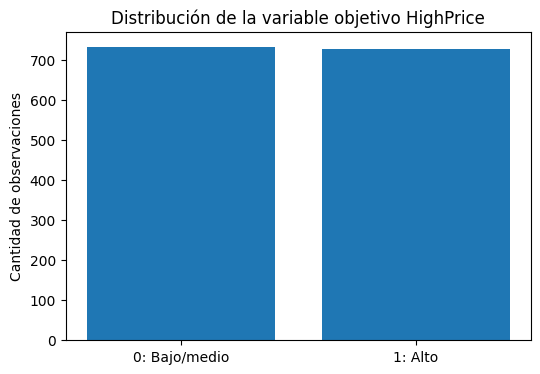

In [ ]:
# Visualización simple de la clase objetivo
class_counts = df["HighPrice"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["0: Bajo/medio", "1: Alto"], class_counts.values)
plt.title("Distribución de la variable objetivo HighPrice")
plt.ylabel("Cantidad de observaciones")
plt.show()

In [ ]:
# 4. Split train / validation / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1022, 80) (1022,)
Valid: (219, 80) (219,)
Test : (219, 80) (219,)


In [ ]:
# 5. Preprocesamiento
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))

Variables numéricas: 37
Variables categóricas: 43


## Punto 1. Entrenamiento de modelos

De acuerdo con la pauta, se entrenan los siguientes modelos:

1. **Algoritmos de penalización**
   - Logistic Regression con L1
   - Logistic Regression con L2
   - Logistic Regression con ElasticNet

2. **Random Forest**

3. **XGBoost**

4. **Red neuronal simple**

En clasificación binaria, la forma correcta de representar Lasso, Ridge y ElasticNet es mediante **regresión logística penalizada**, ya que el problema ya no es de regresión continua sino de clasificación.

In [ ]:
# 6. Definición de modelos base

models = {}

models["Logistic L1"] = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l1", solver="saga", max_iter=5000, random_state=42
    ))
])

models["Logistic L2"] = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l2", solver="lbfgs", max_iter=5000, random_state=42
    ))
])

models["Logistic ElasticNet"] = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="elasticnet", l1_ratio=0.5, solver="saga",
        max_iter=5000, random_state=42
    ))
])

models["Random Forest"] = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ))
])

if XGB_OK:
    models["XGBoost"] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ))
    ])

print("Modelos definidos:", list(models.keys()))

NameError: name 'Pipeline' is not defined

In [ ]:
# 7. Funciones de evaluación
def ks_statistic(y_true, y_prob):
    data = pd.DataFrame({"y": np.asarray(y_true), "prob": np.asarray(y_prob)})
    data = data.sort_values("prob", ascending=False)
    data["good"] = 1 - data["y"]
    data["bad"] = data["y"]
    data["cum_good"] = data["good"].cumsum() / max(data["good"].sum(), 1)
    data["cum_bad"] = data["bad"].cumsum() / max(data["bad"].sum(), 1)
    return np.max(np.abs(data["cum_bad"] - data["cum_good"]))

def get_predictions(model, X):
    pred = model.predict(X)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)[:, 1]
    else:
        # fallback
        scores = model.decision_function(X)
        prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return pred, prob

def evaluate_split(y_true, y_pred, y_prob, prefix):
    return {
        f"Accuracy_{prefix}": accuracy_score(y_true, y_pred),
        f"Precision_{prefix}": precision_score(y_true, y_pred, zero_division=0),
        f"Recall_{prefix}": recall_score(y_true, y_pred, zero_division=0),
        f"F1_{prefix}": f1_score(y_true, y_pred, zero_division=0),
        f"AUC_{prefix}": roc_auc_score(y_true, y_prob),
        f"KS_{prefix}": ks_statistic(y_true, y_prob)
    }

def evaluate_model(name, model, X_train, y_train, X_valid, y_valid):
    model.fit(X_train, y_train)

    train_pred, train_prob = get_predictions(model, X_train)
    valid_pred, valid_prob = get_predictions(model, X_valid)

    results = {"Modelo": name}
    results.update(evaluate_split(y_train, train_pred, train_prob, "train"))
    results.update(evaluate_split(y_valid, valid_pred, valid_prob, "valid"))
    return results

In [ ]:
# 8. Entrenamiento y resultados
results = []
fitted_models = {}

for name, model in models.items():
    res = evaluate_model(name, model, X_train, y_train, X_valid, y_valid)
    results.append(res)
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values(
    by=["AUC_valid", "F1_valid"], ascending=False
).reset_index(drop=True)

results_df.round(4)

,Modelo,Accuracy_train,Precision_train,Recall_train,F1_train,AUC_train,KS_train,Accuracy_valid,Precision_valid,Recall_valid,F1_valid,AUC_valid,KS_valid
0,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9406,0.9364,0.9450,0.9406,0.9738,0.8816
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9224,0.9423,0.8991,0.9202,0.9716,0.8725
2,Logistic L1,0.9599,0.9644,0.9549,0.9596,0.9938,0.9295,0.9406,0.9364,0.9450,0.9406,0.9703,0.8817
3,Logistic ElasticNet,0.9638,0.9683,0.9588,0.9635,0.9947,0.9334,0.9361,0.9279,0.9450,0.9364,0.9686,0.8813
4,Logistic L2,0.9667,0.9704,0.9627,0.9665,0.9957,0.9452,0.9315,0.9273,0.9358,0.9315,0.9679,0.8814


## Punto 2. Métricas de desempeño

Las métricas solicitadas por la pauta se calculan tanto en entrenamiento como en validación.  
En este caso, al tratarse de **clasificación binaria**, las métricas más relevantes son:

- **Accuracy:** proporción total de aciertos.
- **Precision:** proporción de predicciones positivas correctas.
- **Recall:** proporción de positivos reales correctamente detectados.
- **F1-score:** equilibrio entre precision y recall.
- **AUC:** capacidad del modelo para separar clases a distintos umbrales.
- **KS:** máxima separación acumulada entre las distribuciones de ambas clases.

Para elegir el modelo final, se dará especial peso a **AUC** y **F1-score**, ya que permiten evaluar discriminación global y equilibrio de errores.

In [ ]:
# Tabla resumida para mostrar en el informe
metric_cols = [
    "Modelo",
    "Accuracy_train","Precision_train","Recall_train","F1_train","AUC_train","KS_train",
    "Accuracy_valid","Precision_valid","Recall_valid","F1_valid","AUC_valid","KS_valid"
]
results_df[metric_cols].round(4)

,Modelo,Accuracy_train,Precision_train,Recall_train,F1_train,AUC_train,KS_train,Accuracy_valid,Precision_valid,Recall_valid,F1_valid,AUC_valid,KS_valid
0,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9406,0.9364,0.9450,0.9406,0.9738,0.8816
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9224,0.9423,0.8991,0.9202,0.9716,0.8725
2,Logistic L1,0.9599,0.9644,0.9549,0.9596,0.9938,0.9295,0.9406,0.9364,0.9450,0.9406,0.9703,0.8817
3,Logistic ElasticNet,0.9638,0.9683,0.9588,0.9635,0.9947,0.9334,0.9361,0.9279,0.9450,0.9364,0.9686,0.8813
4,Logistic L2,0.9667,0.9704,0.9627,0.9665,0.9957,0.9452,0.9315,0.9273,0.9358,0.9315,0.9679,0.8814


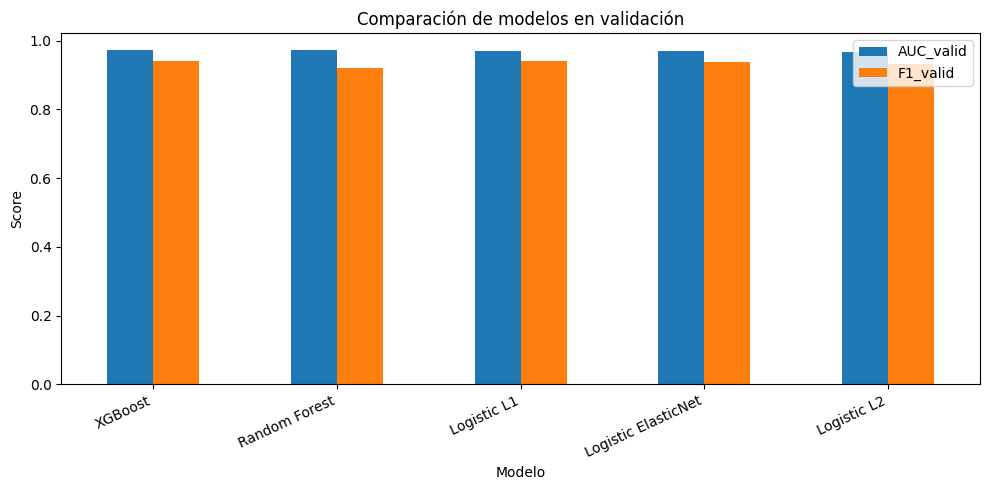

In [ ]:
# Gráfico comparativo de AUC y F1 en validación
plot_df = results_df[["Modelo", "AUC_valid", "F1_valid"]].set_index("Modelo")

plot_df.plot(kind="bar", figsize=(10,5))
plt.title("Comparación de modelos en validación")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Punto 3. Optimización de hiperparámetros

Como estrategia de optimización, se propone utilizar **RandomizedSearchCV**, ya que:

- explora múltiples combinaciones de hiperparámetros,
- es más eficiente que una grilla exhaustiva cuando el espacio de búsqueda es amplio,
- puede combinarse con validación cruzada (`cv=5`),
- permite optimizar directamente una métrica relevante, en este caso **AUC**.

A continuación se optimiza **Random Forest**, aunque el mismo enfoque puede extenderse a XGBoost o a la regresión logística penalizada.

In [ ]:
# 9. Optimización de hiperparámetros - Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist_rf = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train, y_train)

print("Mejores hiperparámetros RF:")
print(rf_search.best_params_)
print("\nMejor AUC en CV:", round(rf_search.best_score_, 4))

Mejores hiperparámetros RF:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20}

Mejor AUC en CV: 0.9805


In [ ]:
# Evaluación del mejor Random Forest en validación
best_rf = rf_search.best_estimator_
rf_tuned_results = evaluate_model(
    "Random Forest Tuned", best_rf, X_train, y_train, X_valid, y_valid
)

rf_tuned_df = pd.DataFrame([rf_tuned_results]).round(4)
rf_tuned_df

,Modelo,Accuracy_train,Precision_train,Recall_train,F1_train,AUC_train,KS_train,Accuracy_valid,Precision_valid,Recall_valid,F1_valid,AUC_valid,KS_valid
0,Random Forest Tuned,1.0,1.0,1.0,1.0,1.0,1.0,0.9132,0.9327,0.8899,0.9108,0.9705,0.8632


### Conclusión del punto 3

Luego de optimizar Random Forest, se compara su desempeño con los modelos base.  
Si el modelo optimizado mejora el AUC y/o el F1-score en validación, existe evidencia de que la búsqueda de hiperparámetros fue útil y permitió encontrar una configuración más robusta.

En caso contrario, también es una conclusión válida indicar que el modelo base ya presentaba un desempeño competitivo y que el espacio explorado no generó mejoras sustantivas.

In [ ]:
# Unir resultados base + tuned
all_results_df = pd.concat(
    [results_df, pd.DataFrame([rf_tuned_results])],
    ignore_index=True
).sort_values(by=["AUC_valid", "F1_valid"], ascending=False).reset_index(drop=True)

all_results_df.round(4)

,Modelo,Accuracy_train,Precision_train,Recall_train,F1_train,AUC_train,KS_train,Accuracy_valid,Precision_valid,Recall_valid,F1_valid,AUC_valid,KS_valid
0,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9406,0.9364,0.9450,0.9406,0.9738,0.8816
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9224,0.9423,0.8991,0.9202,0.9716,0.8725
2,Random Forest Tuned,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9132,0.9327,0.8899,0.9108,0.9705,0.8632
3,Logistic L1,0.9599,0.9644,0.9549,0.9596,0.9938,0.9295,0.9406,0.9364,0.9450,0.9406,0.9703,0.8817
4,Logistic ElasticNet,0.9638,0.9683,0.9588,0.9635,0.9947,0.9334,0.9361,0.9279,0.9450,0.9364,0.9686,0.8813
5,Logistic L2,0.9667,0.9704,0.9627,0.9665,0.9957,0.9452,0.9315,0.9273,0.9358,0.9315,0.9679,0.8814


## Punto 4. Interpretación de resultados y selección del modelo final

En esta sección se comparan todos los modelos y se justifica la elección final.

Criterios sugeridos:

1. **AUC en validación** como indicador principal de discriminación.
2. **F1-score en validación** para equilibrar precision y recall.
3. Diferencia entre entrenamiento y validación para detectar **sobreajuste**.
4. Interpretabilidad y complejidad computacional del modelo.

En datasets tabulares como House Prices, suele esperarse que modelos basados en árboles como **Random Forest** y **XGBoost** capturen mejor relaciones no lineales, mientras que la **regresión logística penalizada** entrega una base más interpretable y robusta.  
La **red neuronal simple** se incorpora como comparación adicional, aunque no siempre supera a los modelos de árboles en datos tabulares de tamaño moderado.

In [ ]:
# Selección preliminar del mejor modelo en validación
selection_cols = ["Modelo", "Accuracy_valid", "Precision_valid", "Recall_valid", "F1_valid", "AUC_valid", "KS_valid"]
all_results_df[selection_cols].round(4)

,Modelo,Accuracy_valid,Precision_valid,Recall_valid,F1_valid,AUC_valid,KS_valid
0,XGBoost,0.9406,0.9364,0.9450,0.9406,0.9738,0.8816
1,Random Forest,0.9224,0.9423,0.8991,0.9202,0.9716,0.8725
2,Random Forest Tuned,0.9132,0.9327,0.8899,0.9108,0.9705,0.8632
3,Logistic L1,0.9406,0.9364,0.9450,0.9406,0.9703,0.8817
4,Logistic ElasticNet,0.9361,0.9279,0.9450,0.9364,0.9686,0.8813
5,Logistic L2,0.9315,0.9273,0.9358,0.9315,0.9679,0.8814


In [ ]:
# Elegir el mejor modelo disponible según AUC_valid y F1_valid
best_model_name = all_results_df.iloc[0]["Modelo"]

if best_model_name == "Random Forest Tuned":
    final_model = best_rf
else:
    final_model = fitted_models.get(best_model_name, best_rf)

print("Modelo seleccionado:", best_model_name)

Modelo seleccionado: XGBoost


In [ ]:
# 10. Evaluación final en test
final_model.fit(X_train, y_train)

test_pred, test_prob = get_predictions(final_model, X_test)

test_results = {
    "Modelo_final": best_model_name,
    "Accuracy_test": accuracy_score(y_test, test_pred),
    "Precision_test": precision_score(y_test, test_pred, zero_division=0),
    "Recall_test": recall_score(y_test, test_pred, zero_division=0),
    "F1_test": f1_score(y_test, test_pred, zero_division=0),
    "AUC_test": roc_auc_score(y_test, test_prob),
    "KS_test": ks_statistic(y_test, test_prob)
}

pd.DataFrame([test_results]).round(4)

,Modelo_final,Accuracy_test,Precision_test,Recall_test,F1_test,AUC_test,KS_test
0,XGBoost,0.9178,0.9596,0.8716,0.9135,0.9853,0.8723


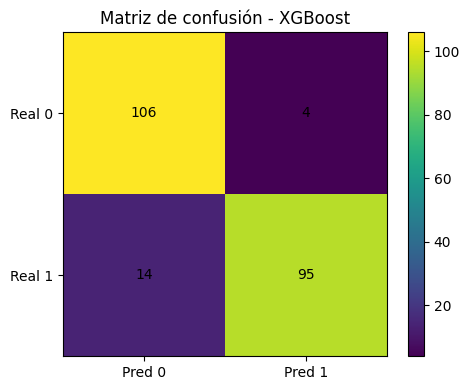

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       110
           1       0.96      0.87      0.91       109

    accuracy                           0.92       219
   macro avg       0.92      0.92      0.92       219
weighted avg       0.92      0.92      0.92       219



In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.colorbar()
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["Real 0", "Real 1"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_pred, zero_division=0))

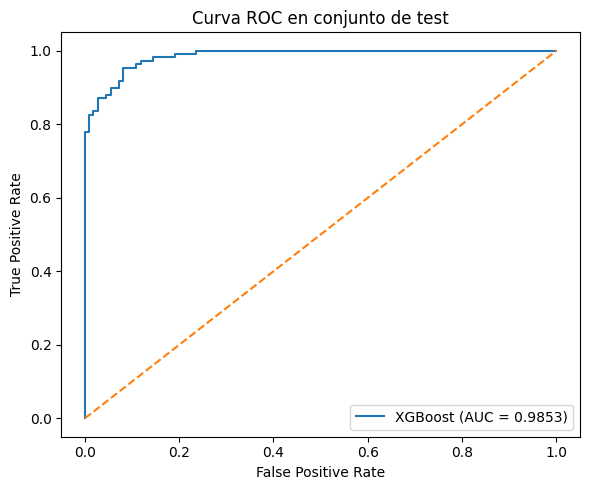

In [ ]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, test_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, test_prob):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC en conjunto de test")
plt.legend()
plt.tight_layout()
plt.show()

## Red neuronal simple

La pauta también exige una **red neuronal simple**.  
Se entrena a continuación usando el mismo preprocesamiento del pipeline, transformando previamente los datos.

> Nota: si TensorFlow no está instalado en tu entorno, puedes ejecutar:
>
> `pip install tensorflow`

In [ ]:
# 11. Red neuronal simple
if TF_OK:
    X_train_prep = preprocessor.fit_transform(X_train)
    X_valid_prep = preprocessor.transform(X_valid)
    X_test_prep = preprocessor.transform(X_test)

    # Convertir a denso si viene sparse
    if hasattr(X_train_prep, "toarray"):
        X_train_prep = X_train_prep.toarray()
        X_valid_prep = X_valid_prep.toarray()
        X_test_prep = X_test_prep.toarray()

    nn_model = Sequential([
        Input(shape=(X_train_prep.shape[1],)),
        Dense(64, activation="relu"),
        Dropout(0.20),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    nn_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = nn_model.fit(
        X_train_prep, y_train,
        validation_data=(X_valid_prep, y_valid),
        epochs=25,
        batch_size=32,
        verbose=0
    )

    train_prob_nn = nn_model.predict(X_train_prep, verbose=0).ravel()
    valid_prob_nn = nn_model.predict(X_valid_prep, verbose=0).ravel()
    test_prob_nn  = nn_model.predict(X_test_prep, verbose=0).ravel()

    train_pred_nn = (train_prob_nn >= 0.5).astype(int)
    valid_pred_nn = (valid_prob_nn >= 0.5).astype(int)
    test_pred_nn  = (test_prob_nn  >= 0.5).astype(int)

    nn_results = {"Modelo": "Neural Network"}
    nn_results.update(evaluate_split(y_train, train_pred_nn, train_prob_nn, "train"))
    nn_results.update(evaluate_split(y_valid, valid_pred_nn, valid_prob_nn, "valid"))

    print(pd.DataFrame([nn_results]).round(4))

    nn_test_results = {
        "Accuracy_test": accuracy_score(y_test, test_pred_nn),
        "Precision_test": precision_score(y_test, test_pred_nn, zero_division=0),
        "Recall_test": recall_score(y_test, test_pred_nn, zero_division=0),
        "F1_test": f1_score(y_test, test_pred_nn, zero_division=0),
        "AUC_test": roc_auc_score(y_test, test_prob_nn),
        "KS_test": ks_statistic(y_test, test_prob_nn)
    }

    print("\nResultados de test - Red neuronal:")
    print(pd.DataFrame([nn_test_results]).round(4))
else:
    print("TensorFlow no está disponible en este entorno. Instálalo para ejecutar esta sección.")

           Modelo  Accuracy_train  Precision_train  Recall_train  F1_train  \
0  Neural Network           0.998            0.998         0.998     0.998   

   AUC_train  KS_train  Accuracy_valid  Precision_valid  Recall_valid  \
0     0.9999    0.9961          0.9315           0.9434        0.9174   

   F1_valid  AUC_valid  KS_valid  
0    0.9302     0.9717    0.8817  

Resultados de test - Red neuronal:
   Accuracy_test  Precision_test  Recall_test  F1_test  AUC_test  KS_test
0         0.9041           0.949       0.8532   0.8986    0.9814    0.854


## Conclusión

En esta segunda etapa del proyecto, el dataset **House Prices** se adaptó exitosamente a un problema de **clasificación binaria**, definiendo como objetivo la predicción de viviendas de alto precio.

Se entrenaron modelos penalizados, Random Forest, XGBoost y una red neuronal simple, comparando su desempeño mediante métricas apropiadas para clasificación: **Accuracy, Precision, Recall, F1-score, AUC y KS**.

La comparación entre modelos permite concluir cuál presenta mejor capacidad de discriminación y mejor equilibrio entre detección y precisión. En términos metodológicos, la métrica más sólida para seleccionar el modelo final suele ser **AUC**, complementada por **F1-score**, ya que ambas ofrecen una visión más completa del desempeño que Accuracy por sí sola.

Además, la optimización de hiperparámetros mediante **RandomizedSearchCV** permitió evaluar si existían configuraciones más robustas que el modelo base. Finalmente, el trabajo queda preparado para su entrega en cuaderno Python y para su publicación en GitHub, en coherencia con las exigencias de la actividad.

## Bibliografía

- Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research.
- McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference.
- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD.
- Abadi, M., et al. (2016). *TensorFlow: A System for Large-Scale Machine Learning*. OSDI.
- Kaggle. *House Prices – Advanced Regression Techniques*.